# Hillstrom Email Marketing

## Dataset Overview

The Hillstrom Email Marketing Dataset comes from an email marketing experiment conducted by Kevin Hillstrom.

The dataset contains **64,000 customers** and **12 columns**. Each row represents one customer who had purchase activity during the 12 months before the experiment.

Customers were randomly assigned to one of three groups:

- `Mens E-Mail`: received an email promoting men's merchandise;
- `Womens E-Mail`: received an email promoting women's merchandise;
- `No E-Mail`: received no email and served as the control group.

Customer behavior was observed for two weeks after the campaign.

### Dataset Variables

The 12 columns can be grouped into customer characteristics, treatment assignment, and post-campaign outcomes.

| Column | Description |
|---|---|
| `recency` | Number of months since the customer's last purchase | Customer characteristic |
| `history_segment` | Category representing the customer's historical spending level |
| `history` | Total amount spent by the customer during the previous 12 months |
| `mens` | Whether the customer had previously purchased men's merchandise |
| `womens` | Whether the customer had previously purchased women's merchandise |
| `zip_code` | Customer's geographic area: Rural, Surburban, or Urban |
| `newbie` | Whether the customer is a new customer |
| `channel` | Customer's historical purchasing channel: Web, Phone, or Multichannel |
| `segment` | Email campaign assigned to the customer |
| `visit` | Whether the customer visited the website during the post-campaign period |
| `conversion` | Whether the customer made a purchase during the post-campaign period |
| `spend` | Amount spent by the customer during the post-campaign period |

The customer characteristics describe information available before the email campaign, while `segment` represents the campaign assignment and `visit`, `conversion`, and `spend` represent post-campaign behavior.



In [1]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}

PALETTE = list(COLORS.values())


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "hillstrom"
    / "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
)

if not RAW_PATH.exists():
    raise FileNotFoundError(
        "Hillstrom raw dataset was not found at:\n"
        f"{RAW_PATH}"
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Raw dataset:",
    RAW_PATH,
)

Project root: d:\thao\d\uplif_model\uplif_customer_selection
Raw dataset: d:\thao\d\uplif_model\uplif_customer_selection\data\raw\hillstrom\Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


In [3]:
raw_df = pd.read_csv(RAW_PATH)
df = raw_df.copy()
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 64,000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


## Data Overview

In [4]:
schema_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[col].dtype) for col in df.columns],
    "non_null": [df[col].notna().sum() for col in df.columns],
    "null": [df[col].isna().sum() for col in df.columns],
    "unique": [df[col].nunique(dropna=True) for col in df.columns],
})

schema_profile["null_pct"] = (schema_profile["null"]/len(df)*100)
display(schema_profile)


,column,dtype,non_null,null,unique,null_pct
0,recency,int64,64000,0,12,0.0000
1,history_segment,object,64000,0,7,0.0000
2,history,float64,64000,0,34833,0.0000
3,mens,int64,64000,0,2,0.0000
4,womens,int64,64000,0,2,0.0000
5,zip_code,object,64000,0,3,0.0000
6,newbie,int64,64000,0,2,0.0000
7,channel,object,64000,0,3,0.0000
8,segment,object,64000,0,3,0.0000
9,visit,int64,64000,0,2,0.0000


In [5]:
column_samples = []

for column in df.columns:
    values = (df[column].dropna().unique())

    sample_values = values[:8]

    column_samples.append({
        "column": column,
        "dtype": str(df[column].dtype),
        "n_unique": df[column].nunique(dropna=True),
        "sample_values": sample_values,
    })

column_samples = pd.DataFrame(column_samples)

display(column_samples)

,column,dtype,n_unique,sample_values
0,recency,int64,12,"[10, 6, 7, 9, 2, 1, 5, 4]"
1,history_segment,object,7,"[2) $100 - $200, 3) $200 - $350, 5) $500 - $75..."
2,history,float64,34833,"[142.44, 329.08, 180.65, 675.83, 45.34, 134.83..."
3,mens,int64,2,"[1, 0]"
4,womens,int64,2,"[0, 1]"
5,zip_code,object,3,"[Surburban, Rural, Urban]"
6,newbie,int64,2,"[0, 1]"
7,channel,object,3,"[Phone, Web, Multichannel]"
8,segment,object,3,"[Womens E-Mail, No E-Mail, Mens E-Mail]"
9,visit,int64,2,"[0, 1]"


In [6]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    display(duplicate_rows)
else:
    print("No exact duplicate rows found.")

Duplicate rows: 6,562


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
16,5,1) $0 - $100,29.9900,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0000
20,9,1) $0 - $100,29.9900,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0000
23,2,1) $0 - $100,29.9900,0,1,Urban,1,Phone,No E-Mail,0,0,0.0000
33,9,1) $0 - $100,29.9900,1,0,Surburban,1,Phone,Mens E-Mail,0,0,0.0000
34,3,1) $0 - $100,29.9900,1,0,Rural,0,Web,Womens E-Mail,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
63942,3,1) $0 - $100,29.9900,1,0,Urban,1,Phone,No E-Mail,0,0,0.0000
63952,10,1) $0 - $100,29.9900,1,0,Rural,1,Web,No E-Mail,0,0,0.0000
63955,1,1) $0 - $100,29.9900,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0000
63982,5,1) $0 - $100,29.9900,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0000


In [7]:
numeric_columns = [
    "recency",
    "history",
    "spend",
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
recency,"64,000.0000",5.7637,3.5076,1.0000,2.0000,6.0000,9.0000,12.0000
history,"64,000.0000",242.0857,256.1586,29.9900,64.6600,158.1100,325.6575,"3,345.9300"
spend,"64,000.0000",1.0509,15.0364,0.0000,0.0000,0.0000,0.0000,499.0000


In [8]:
history_labels = [
    "1) $0 - $100",
    "2) $100 - $200",
    "3) $200 - $350",
    "4) $350 - $500",
    "5) $500 - $750",
    "6) $750 - $1,000",
    "7) $1,000 +",
]

expected_segment = pd.cut(
    df["history"],
    bins=[0,100,200,350,500,750,1000,np.inf,],
    labels=history_labels,
    right=False,
)

segment_mismatch = (df["history_segment"]!= expected_segment.astype(str))

print("History segment mismatches:", f"{segment_mismatch.sum():,}",
)

if segment_mismatch.any():
    display(df.loc[segment_mismatch,["history","history_segment",],].head(20))

History segment mismatches: 0


In [9]:
binary_columns = [
    "visit",
    "conversion",
    "mens",
    "womens",
    "newbie"
]

display(df[binary_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
visit,"64,000.0000",0.1468,0.3539,0.0000,0.0000,0.0000,0.0000,1.0000
conversion,"64,000.0000",0.0090,0.0946,0.0000,0.0000,0.0000,0.0000,1.0000
mens,"64,000.0000",0.5510,0.4974,0.0000,0.0000,1.0000,1.0000,1.0000
womens,"64,000.0000",0.5497,0.4975,0.0000,0.0000,1.0000,1.0000,1.0000
newbie,"64,000.0000",0.5022,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000


### Data Quality Findings

- No missing values were found in the dataset.
- Numeric variables fall within reasonable ranges, and binary variables contain only `0/1` values.
- `history_segment` is consistent with the numeric `history` values.
- **6,562 rows are exact repetitions of an earlier observed row.** Because the dataset does not contain a unique customer identifier, these rows cannot be confirmed as duplicated customer records and are therefore retained.


## Data Cleaning


In [10]:
categorical_columns = [
    "history_segment",
    "zip_code",
    "channel",
    "segment",
]

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [11]:
df["history_segment"] = (
    df["history_segment"]
    .str.replace(r"^\d+\)\s*", "", regex=True)
    .str.replace(" +", "+", regex=False)
)

In [12]:
df["zip_code"] = df["zip_code"].replace(
    "Surburban",
    "Suburban",
)

In [13]:
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,$100 - $200,142.4400,1,0,Suburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,$200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,$100 - $200,180.6500,0,1,Suburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,$500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,$0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


## Experimental Design & Causal Assumptions

Before analyzing treatment effects, I check whether the observed data are consistent with the randomized experimental design using the following diagnostics:

1. **Treatment allocation** — whether the observed treatment-group sizes are consistent with the expected allocation.
2. **Covariate balance** — whether pre-treatment customer characteristics are similarly distributed across treatment groups.
3. **Positivity and overlap** — whether each observed level of the checked pre-treatment variables is represented across all treatment groups.
4. **Temporal ordering** — whether the variables used as features were measured before treatment.
5. **Leakage** — whether any post-treatment variables are included as model inputs.

These checks are used to identify obvious problems in the observed experimental data before proceeding with treatment-effect analysis.

In [14]:
segment_summary = (df["segment"].value_counts().rename("customers").to_frame())

segment_summary["percentage"] = (segment_summary["customers"]/len(df)*100)

display(segment_summary)


,customers,percentage
segment,,
Womens E-Mail,21387,33.4172
Mens E-Mail,21307,33.2922
No E-Mail,21306,33.2906


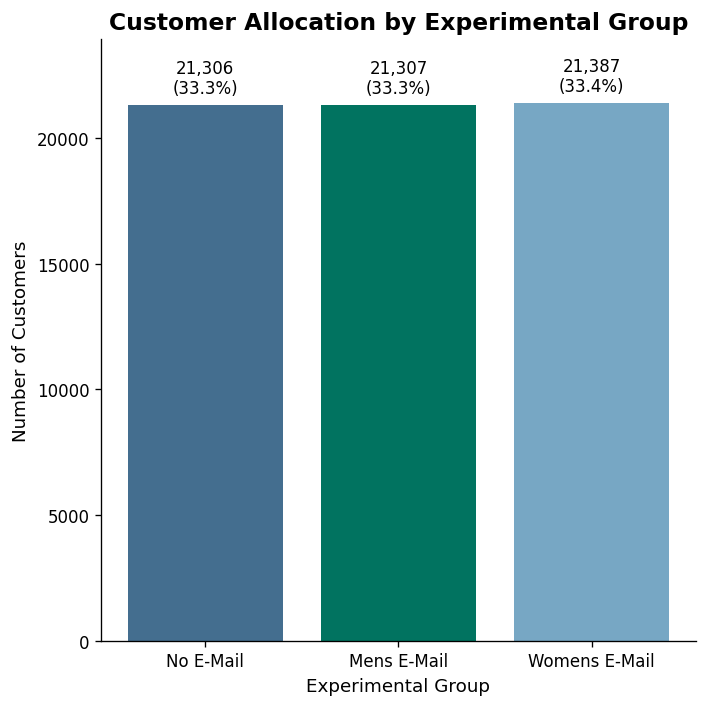

In [15]:
segment_order = [
    "No E-Mail",
    "Mens E-Mail",
    "Womens E-Mail"
]

segment_colors = [
    COLORS["rainy_lake"],
    COLORS["pacific_green"],
    COLORS["serene_sea"],
]

counts = (df["segment"].value_counts().reindex(segment_order))

fig, ax = plt.subplots(figsize=(6, 6))

bars = ax.bar(
    counts.index,
    counts.values,
    color=segment_colors,
)

ax.set_title("Customer Allocation by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Number of Customers")

for bar, value in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + counts.max() * 0.015,
        f"{value:,}\n({value / len(df):.1%})",
        ha="center",
        va="bottom",
    )

ax.set_ylim(0, counts.max() * 1.12)

plt.tight_layout()
plt.show()


In [16]:
from scipy.stats import chisquare

observed = segment_summary["customers"].values
expected = np.repeat(len(df)/3,3)

chi2, p_value = chisquare(observed, f_exp=expected,)

print(f"Chi-Square statistics {chi2:.3f}")
print(f"P-value: {p_value:.3f}")


Chi-Square statistics 0.203
P-value: 0.904


In [17]:
balance_df = pd.get_dummies(
    df[
        [
            "segment",
            "recency",
            "history",
            "mens",
            "womens",
            "newbie",
            "zip_code",
            "channel",
        ]
    ],
    columns=["zip_code","channel",],
    dtype=int,
)

def calculate_smd(data, feature, treatment_group):
    treatment = data.loc[data["segment"] == treatment_group,feature,]
    control = data.loc[data["segment"] == "No E-Mail",feature,]
    pooled_std = np.sqrt((treatment.var() + control.var())/2)

    return (treatment.mean() - control.mean()) / pooled_std

In [18]:
balance_features = [column for column in balance_df.columns if column != "segment"]

balance_results = []

for treatment_group in ["Mens E-Mail","Womens E-Mail",]:
    for feature in balance_features:
        smd = calculate_smd(balance_df,feature,treatment_group,)

        balance_results.append({
            "comparison":
                f"{treatment_group} vs No E-Mail",
            "feature": feature,
            "smd": smd,
            "abs_smd": abs(smd),
        })

balance_results = pd.DataFrame(balance_results)

In [19]:
balance_table = (balance_results.pivot(index="feature",columns="comparison",values="smd",))

display(balance_table.round(3))

comparison,Mens E-Mail vs No E-Mail,Womens E-Mail vs No E-Mail
feature,,
channel_Multichannel,-0.0040,-0.0050
channel_Phone,-0.0080,0.0090
channel_Web,0.0110,-0.0050
history,0.0080,0.0070
mens,-0.0050,-0.0090
newbie,-0.0010,0.0030
recency,0.0070,0.0050
womens,0.0080,0.0050
zip_code_Rural,0.0140,0.0040


In [20]:
max_balance = (balance_results.sort_values("abs_smd",ascending=False,).iloc[0])

print("Maximum absolute SMD:",f"{max_balance['abs_smd']:.3f}",)

print("Feature:",max_balance["feature"],)

print("Comparison:",max_balance["comparison"],)

Maximum absolute SMD: 0.014
Feature: zip_code_Rural
Comparison: Mens E-Mail vs No E-Mail


In [21]:
overlap_columns = [
    "recency",
    "history_segment",
    "mens",
    "womens",
    "newbie",
    "zip_code",
    "channel",
]

overlap_results = []

for column in overlap_columns:
    table = pd.crosstab(df[column],df["segment"],)

    overlap_results.append({
        "feature": column,
        "zero_cells": (table == 0).sum().sum(),
        "minimum_group_size": table.min().min(),
    })

overlap_results = pd.DataFrame(overlap_results)

display(overlap_results)

,feature,zero_cells,minimum_group_size
0,recency,0,767
1,history_segment,0,416
2,mens,0,9519
3,womens,0,9558
4,newbie,0,10611
5,zip_code,0,3139
6,channel,0,2577


The observed data are consistent with the documented randomized experiment.

- Treatment allocation does not show evidence of a sample-ratio mismatch.
- Pre-treatment customer characteristics are well balanced across the three experimental groups.
- Every observed level of the checked pre-treatment variables appears in all three treatment groups.
- The customer-history variables were recorded before treatment, while `visit`, `conversion`, and `spend` are post-treatment outcomes and are not used as input features.

Overall, I do not find an obvious problem with the observed experimental design, so I proceed with treatment-effect analysis.

## Exploratory Data Analysis

### Who are the customers in the dataset?


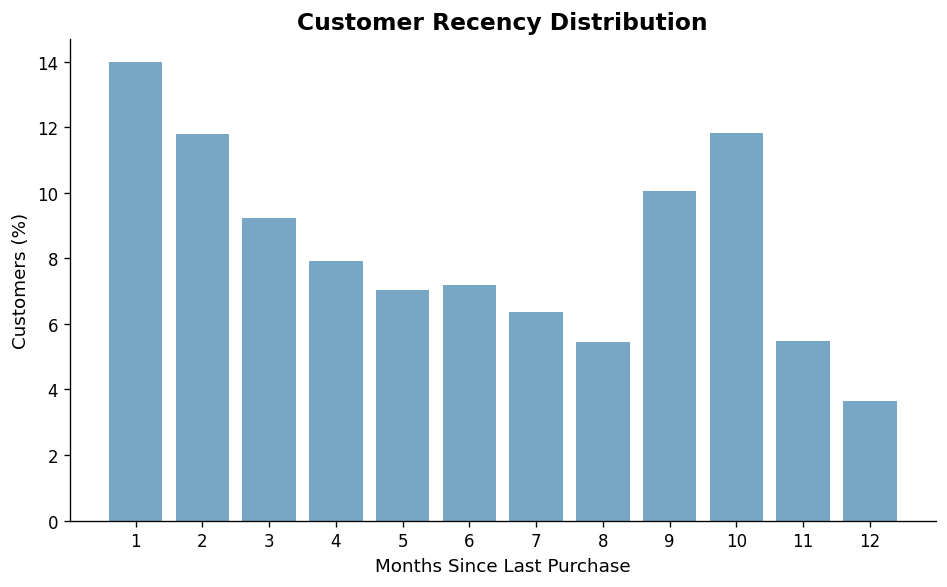

In [22]:
recency_pct = (df["recency"].value_counts(normalize=True).sort_index()*100)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(recency_pct.index, recency_pct.values, color=COLORS["serene_sea"])
ax.set_title("Customer Recency Distribution")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Customers (%)")
ax.set_xticks(recency_pct.index)
plt.tight_layout()
plt.show()

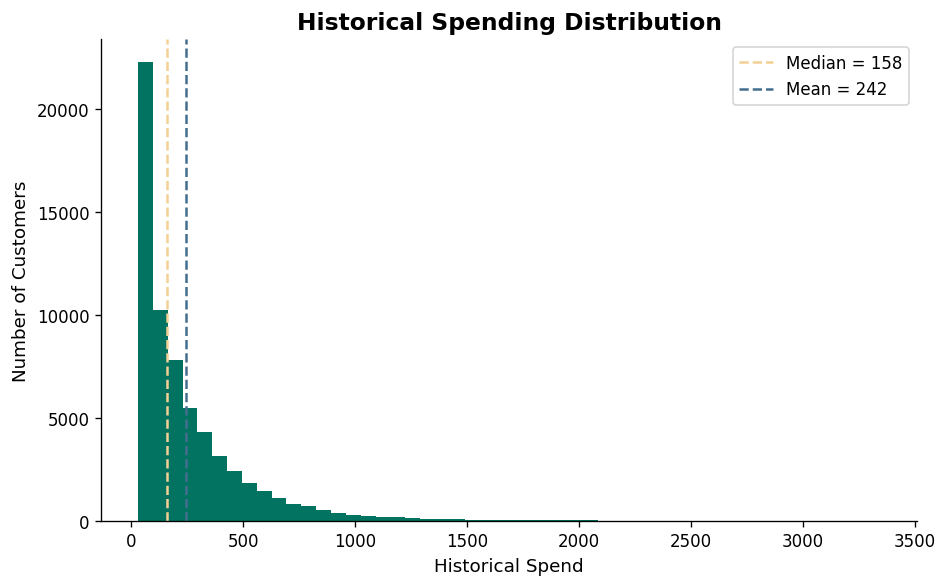

In [23]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(df["history"], bins=50, color=COLORS["pacific_green"],)
ax.axvline(
    df["history"].median(), 
    color=COLORS["bungalow_maple"], 
    linestyle="--", 
    label=f"Median = {df["history"].median():.0f}",
)
ax.axvline(
    df["history"].mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    label=f"Mean = {df['history'].mean():.0f}",
)

ax.set_title("Historical Spending Distribution")
ax.set_xlabel("Historical Spend")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()


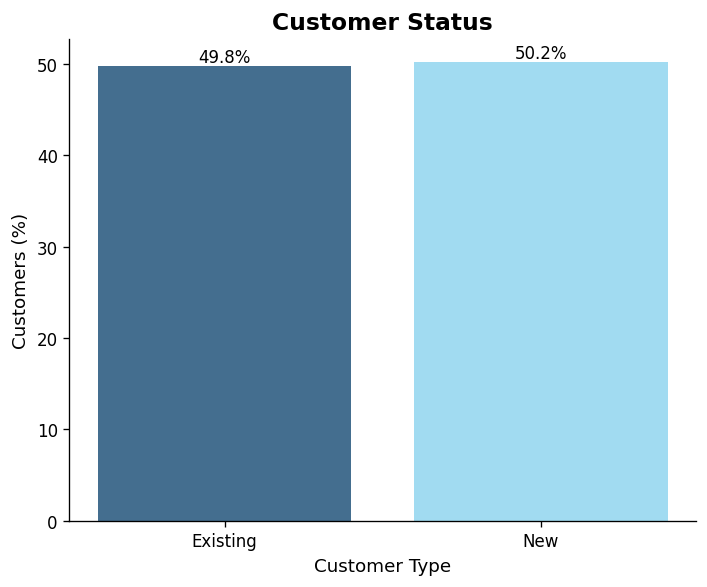

In [24]:
newbie_pct = (df["newbie"].value_counts(normalize=True).sort_index()*100)

newbie_pct.index = ["Existing", "New"]

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(
    newbie_pct.index,
    newbie_pct.values,
    color=[
        COLORS["rainy_lake"],
        COLORS["sora_blue"],
    ],

)
ax.set_title("Customer Status")
ax.set_xlabel("Customer Type")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,newbie_pct.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

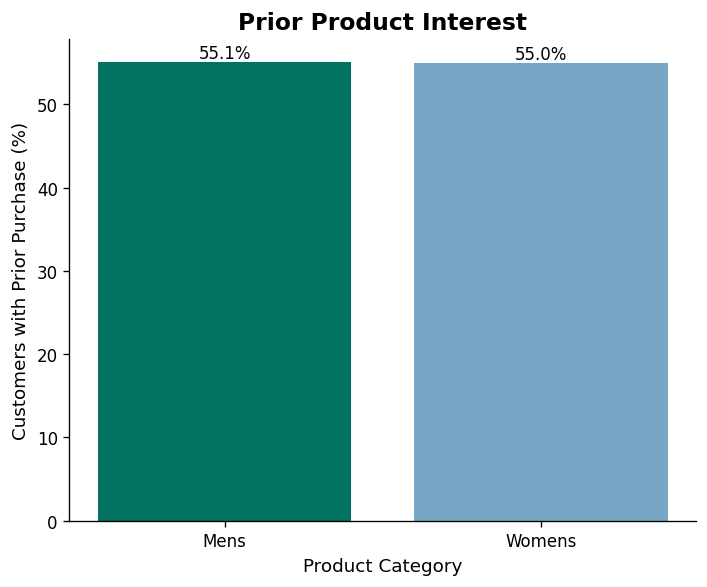

In [25]:
product_affinity = pd.Series({
    "Mens": df["mens"].mean() * 100,
    "Womens": df["womens"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    product_affinity.index,
    product_affinity.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Prior Product Interest")
ax.set_xlabel("Product Category")
ax.set_ylabel("Customers with Prior Purchase (%)")

for bar, value in zip(bars,product_affinity.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [26]:
cross_tab_pct = pd.crosstab(
    df['mens'], 
    df['womens'], 
    normalize='all'
) * 100

print(cross_tab_pct.round(2))

womens       0       1
mens                  
0       0.0000 44.9000
1      45.0300 10.0800


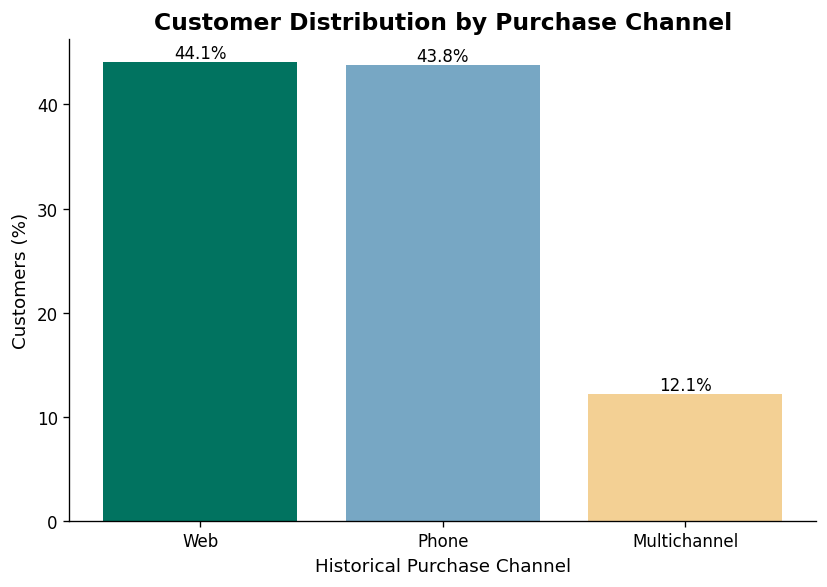

In [27]:
channel_pct = (df["channel"].value_counts(normalize=True)* 100)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    channel_pct.index,
    channel_pct.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
        COLORS["bungalow_maple"],
    ],
)

ax.set_title("Customer Distribution by Purchase Channel")
ax.set_xlabel("Historical Purchase Channel")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,channel_pct.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Customer Population Findings

- **Recency:** Customers span all 12 recency groups, so the dataset includes both recent and less recent purchasers.
- **Historical spending:** Most customers are concentrated in the lower and middle spending ranges, while the highest-spending segments contain relatively few observations.
- **Purchase channel:** Customers have previously purchased through Web, Phone, or both channels.
- **Shopping area:** Rural, Suburban, and Urban customers are all represented in the dataset.
- **Product affinity:** About **45.0%** of customers previously purchased only Mens products, **44.9%** only Womens products, and **10.1%** purchased both.

These customer characteristics provide the main dimensions I examine in the subgroup analysis below.

### What are the behavioral outcomes following the campaign?


In [28]:
outcome_summary = pd.Series({
    "Visit rate (%)":
        df["visit"].mean() * 100,

    "Conversion rate (%)":
        df["conversion"].mean() * 100,

    "Customers with positive spend (%)":
        (df["spend"] > 0).mean() * 100,

    "Average spend":
        df["spend"].mean(),
})

display(outcome_summary.to_frame("value"))

,value
Visit rate (%),14.6781
Conversion rate (%),0.9031
Customers with positive spend (%),0.9031
Average spend,1.0509


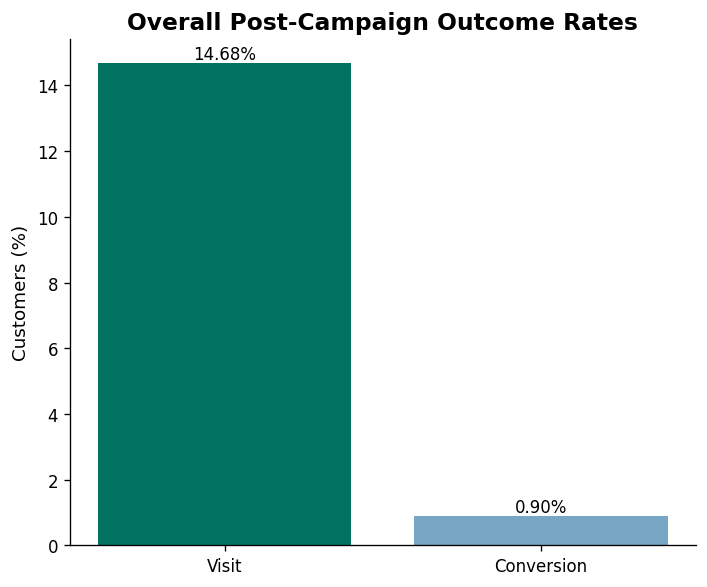

In [29]:
outcome_rates = pd.Series({
    "Visit":
        df["visit"].mean() * 100,

    "Conversion":
        df["conversion"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    outcome_rates.index,
    outcome_rates.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Overall Post-Campaign Outcome Rates")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,outcome_rates.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

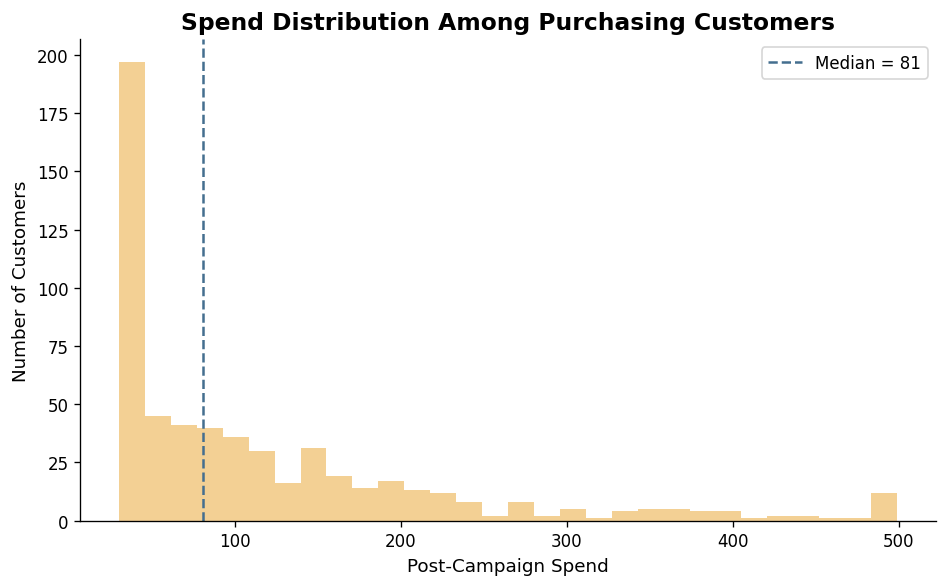

In [30]:
positive_spend = df.loc[df["spend"] > 0,"spend",]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(positive_spend,bins=30,color=COLORS["bungalow_maple"],)

ax.axvline(
    positive_spend.median(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    label=f"Median = {positive_spend.median():.0f}",
)

ax.set_title("Spend Distribution Among Purchasing Customers")
ax.set_xlabel("Post-Campaign Spend")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

### Post-Campaign Outcome Behavior

Customer response after the campaign is relatively sparse, especially at the purchase stage.

- **14.68%** of customers visited after the campaign.
- Only **0.90%** converted.
- The proportion of customers with positive spend is also **0.90%**, matching the conversion rate at the aggregate level.
- Average spend across the full population is only **1.05** because most customers made no purchase.
- Among customers who did purchase, spend is right-skewed with a median of approximately **81**, while a smaller number of customers spent substantially more.


### Do the outcomes differ between the treatments?


In [31]:
treatment_outcomes = (
    df.groupby("segment")
    .agg(
        customers=("segment", "size"),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
        average_spend=("spend", "mean"),
    )
    .reindex([
        "No E-Mail",
        "Mens E-Mail",
        "Womens E-Mail",
    ])
)

treatment_outcomes["visit_rate"] *= 100

treatment_outcomes["conversion_rate"] *= 100

display(treatment_outcomes.round(3))

,customers,visit_rate,conversion_rate,average_spend
segment,,,,
No E-Mail,21306,10.6170,0.5730,0.6530
Mens E-Mail,21307,18.2760,1.2530,1.4230
Womens E-Mail,21387,15.1400,0.8840,1.0770


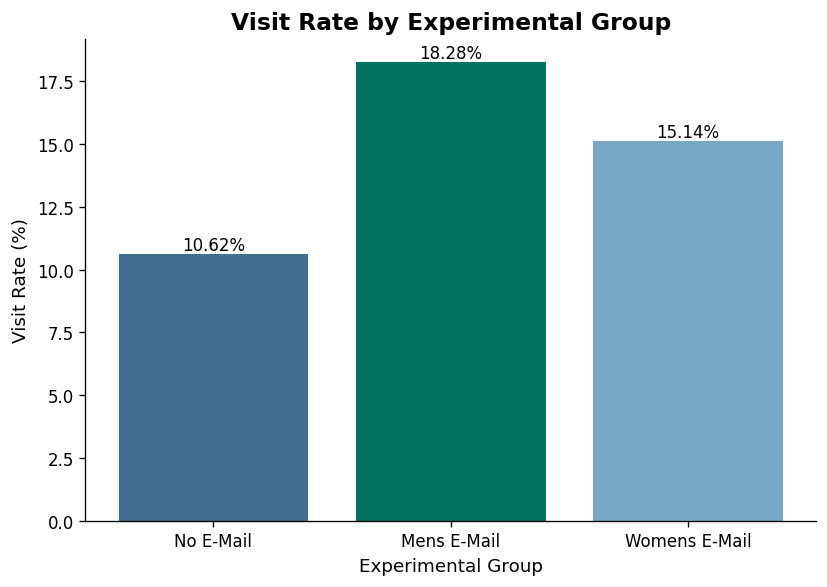

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["visit_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Visit Rate by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Visit Rate (%)")

for bar, value in zip(bars,treatment_outcomes["visit_rate"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

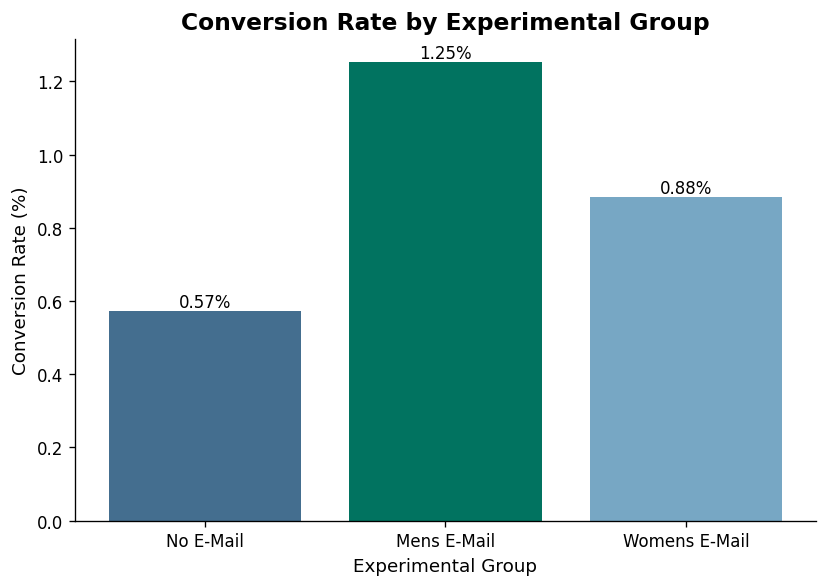

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["conversion_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Conversion Rate by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Conversion Rate (%)")

for bar, value in zip(bars,treatment_outcomes["conversion_rate"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

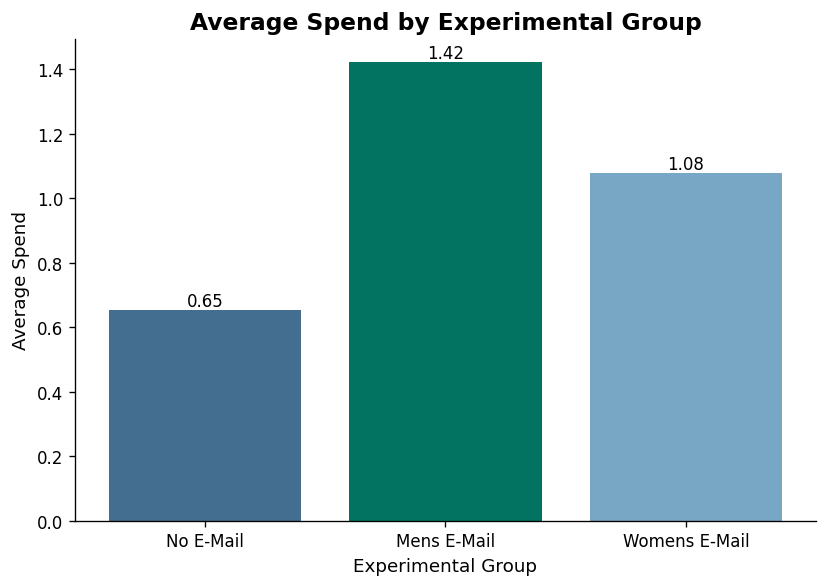

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["average_spend"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Average Spend by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Average Spend")

for bar, value in zip(bars,treatment_outcomes["average_spend"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [35]:
control = treatment_outcomes.loc[
    "No E-Mail"
]

raw_effects = pd.DataFrame({
    "Mens E-Mail": [
        treatment_outcomes.loc["Mens E-Mail","visit_rate",] - control["visit_rate"],

        treatment_outcomes.loc["Mens E-Mail","conversion_rate",] - control["conversion_rate"],

        treatment_outcomes.loc["Mens E-Mail","average_spend",] - control["average_spend"],
    ],

    "Womens E-Mail": [
        treatment_outcomes.loc["Womens E-Mail","visit_rate",] - control["visit_rate"],

        treatment_outcomes.loc["Womens E-Mail","conversion_rate",] - control["conversion_rate"],

        treatment_outcomes.loc["Womens E-Mail","average_spend",] - control["average_spend"],
    ],
}, index=[
    "Visit rate difference (pp)",
    "Conversion rate difference (pp)",
    "Average spend difference",
])

display(raw_effects.round(3))

,Mens E-Mail,Womens E-Mail
Visit rate difference (pp),7.6590,4.5230
Conversion rate difference (pp),0.6810,0.3110
Average spend difference,0.7700,0.4240


### Outcomes Across Experimental Groups

The observed outcomes differ across the three experimental groups.

| Experimental group | Visit rate | Conversion rate | Average spend |
|---|---:|---:|---:|
| No E-Mail | 10.62% | 0.57% | 0.65 |
| Mens E-Mail | 18.28% | 1.25% | 1.42 |
| Womens E-Mail | 15.14% | 0.88% | 1.08 |

Compared with `No E-Mail`:

- `Mens E-Mail` has a **7.66 pp** higher visit rate, a **0.68 pp** higher conversion rate, and **0.77** higher average spend.
- `Womens E-Mail` has a **4.52 pp** higher visit rate, a **0.31 pp** higher conversion rate, and **0.42** higher average spend.

Here, **pp means percentage points**. For example, the visit uplift is calculated as the treatment visit rate (%) minus the control visit rate (%).

Both email groups have higher average outcomes than the control group, with larger raw differences for `Mens E-Mail` across all three outcomes.

### How does treatment affect customers with different feature characteristics?

After comparing the average outcomes across experimental groups, I next examine whether visit uplift varies across customer groups.

For each feature, I compare the visit rate of `Mens E-Mail` and `Womens E-Mail` with the `No E-Mail` control within the same subgroup.

In [36]:
def subgroup_uplift(
    data,
    group_columns,
    treatment,
    outcome="visit",
):
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    subset = data[data["segment"].isin([treatment,"No E-Mail",])]

    summary = (
        subset
        .groupby(group_columns + ["segment"],observed=True,)[outcome]
        .agg(rate="mean",n="size",positives="sum",)
        .reset_index()
    )

    rates = summary.pivot_table(
        index=group_columns,
        columns="segment",
        values="rate",
        aggfunc="first",
    )

    counts = summary.pivot_table(
        index=group_columns,
        columns="segment",
        values="n",
        aggfunc="first",
    )

    positives = summary.pivot_table(
        index=group_columns,
        columns="segment",
        values="positives",
        aggfunc="first",
    )

    result = pd.DataFrame(index=rates.index)

    result["treatment_rate_pct"] = rates[treatment] * 100
    result["control_rate_pct"] = rates["No E-Mail"] * 100
    result["raw_uplift_pp"] = (result["treatment_rate_pct"] - result["control_rate_pct"])
    result["n_treatment"] = counts[treatment]
    result["n_control"] = counts["No E-Mail"]
    result["positive_treatment"] = positives[treatment]
    result["positive_control"] = positives["No E-Mail"]

    return result

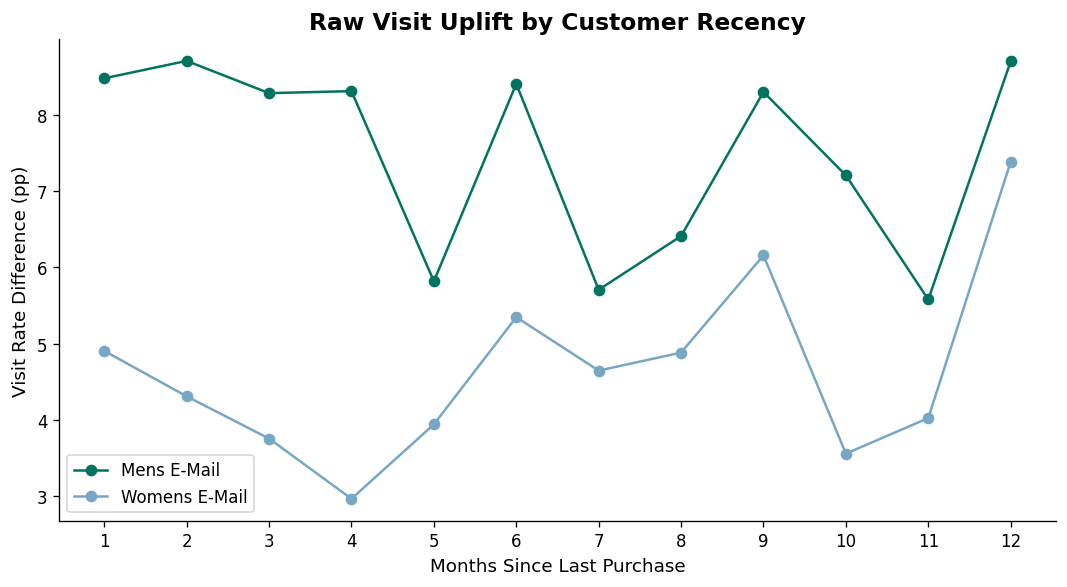

In [37]:
mens_recency = subgroup_uplift(df, "recency", "Mens E-Mail", outcome="visit")
womens_recency = subgroup_uplift(df, "recency", "Womens E-Mail", outcome="visit")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    mens_recency.index,
    mens_recency["raw_uplift_pp"], 
    marker="o",
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.plot(
    womens_recency.index,
    womens_recency["raw_uplift_pp"],  
    marker="o",
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.set_title("Raw Visit Uplift by Customer Recency")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(range(1, 13))
ax.legend()

plt.tight_layout()
plt.show()

In [38]:
product_df = df.copy()

product_df["product_affinity"] = np.select(
    [
        (product_df["mens"] == 0) & (product_df["womens"] == 0),
        (product_df["mens"] == 1) & (product_df["womens"] == 0),
        (product_df["mens"] == 0) & (product_df["womens"] == 1),
        (product_df["mens"] == 1) & (product_df["womens"] == 1),
    ],
    [
        "Neither",
        "Mens only",
        "Womens only",
        "Both",
    ],
    default="Unknown",
)

affinity_order = [
    "Neither",
    "Mens only",
    "Womens only",
    "Both",
]

mens_affinity = (subgroup_uplift(product_df,"product_affinity","Mens E-Mail",).reindex(affinity_order))
womens_affinity = (subgroup_uplift(product_df,"product_affinity","Womens E-Mail",).reindex(affinity_order))

affinity_uplift = pd.DataFrame({
    "Mens E-Mail": mens_affinity["raw_uplift_pp"],
    "Womens E-Mail": womens_affinity["raw_uplift_pp"],
})

display(affinity_uplift.round(2))

,Mens E-Mail,Womens E-Mail
product_affinity,,
Neither,NaN,NaN
Mens only,6.9200,1.1100
Womens only,7.0600,7.4000
Both,13.4400,7.1100


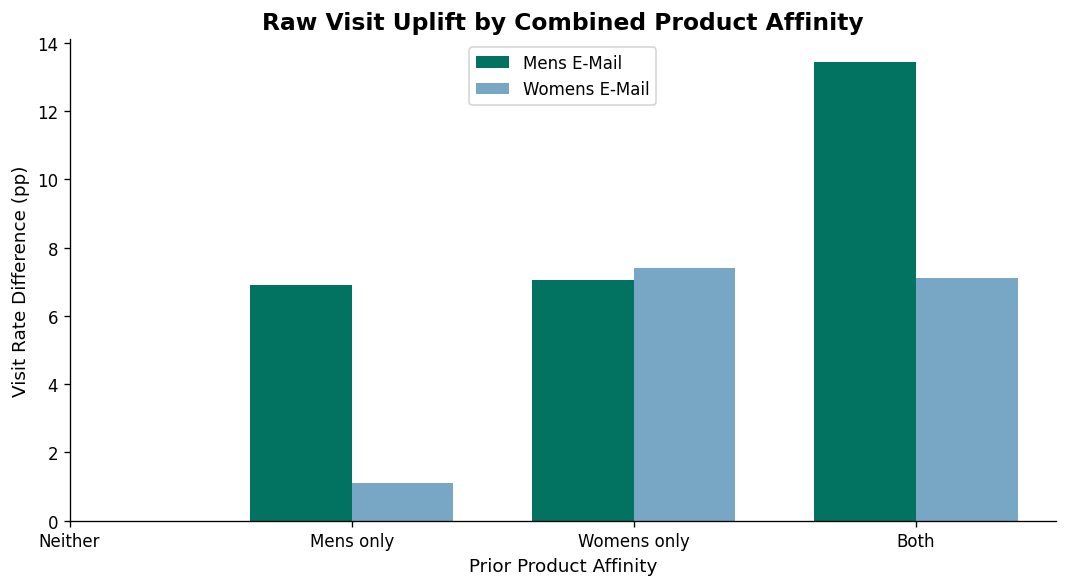

In [39]:
x = np.arange(len(affinity_order))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    x - width / 2,
    affinity_uplift["Mens E-Mail"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    affinity_uplift["Womens E-Mail"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)


ax.set_title("Raw Visit Uplift by Combined Product Affinity")
ax.set_xlabel("Prior Product Affinity")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(affinity_order)
ax.legend()

plt.tight_layout()
plt.show()

In [40]:
channel_order = [
    "Web",
    "Phone",
    "Multichannel",
]

mens_channel = (subgroup_uplift(df,"channel","Mens E-Mail",).reindex(channel_order))

womens_channel = (subgroup_uplift(df,"channel","Womens E-Mail",).reindex(channel_order))

channel_uplift = pd.DataFrame({
    "Mens E-Mail": mens_channel["raw_uplift_pp"],
    "Womens E-Mail": womens_channel["raw_uplift_pp"],
})

display(channel_uplift.round(2))

,Mens E-Mail,Womens E-Mail
channel,,
Web,7.5600,4.5700
Phone,7.5600,4.4600
Multichannel,8.2900,4.7100


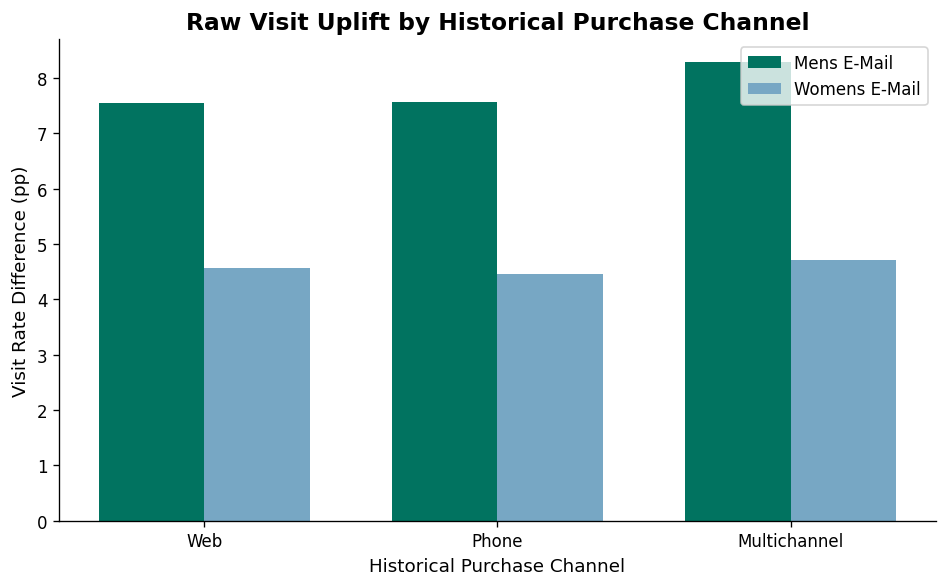

In [41]:
x = np.arange(len(channel_order))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    channel_uplift["Mens E-Mail"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    channel_uplift["Womens E-Mail"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.set_title("Raw Visit Uplift by Historical Purchase Channel")
ax.set_xlabel("Historical Purchase Channel")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(channel_order)
ax.legend()

plt.tight_layout()
plt.show()

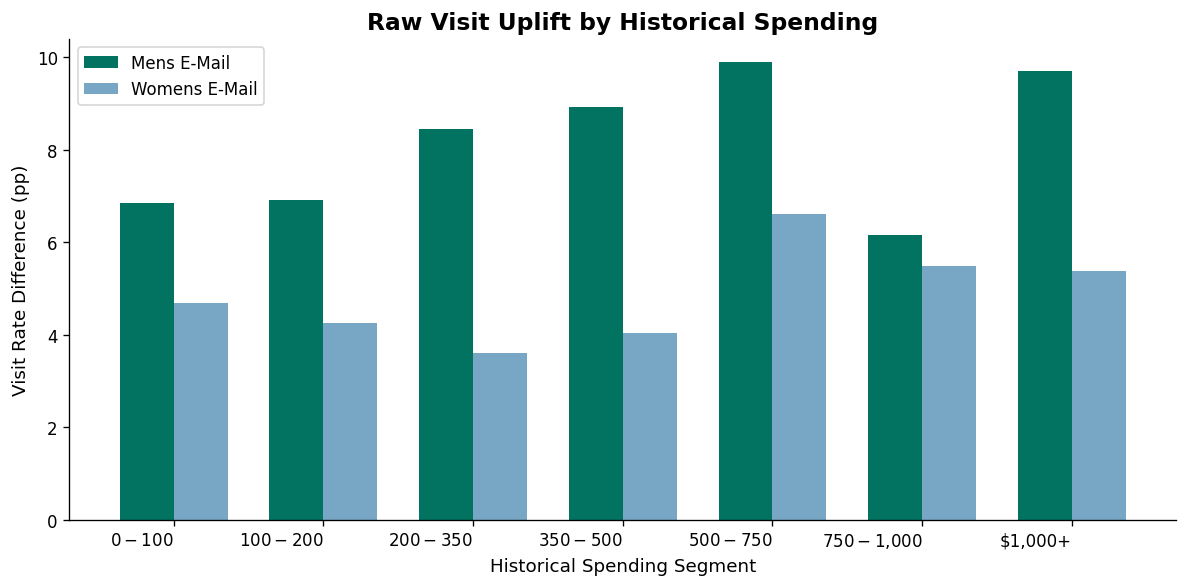

In [42]:
history_order = [
    "$0 - $100",
    "$100 - $200",
    "$200 - $350",
    "$350 - $500",
    "$500 - $750",
    "$750 - $1,000",
    "$1,000+",
]

mens_history = (subgroup_uplift(df,"history_segment","Mens E-Mail",).reindex(history_order))

womens_history = (subgroup_uplift(df,"history_segment","Womens E-Mail",).reindex(history_order))

x = np.arange(len(history_order))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    mens_history["raw_uplift_pp"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    womens_history["raw_uplift_pp"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.set_title("Raw Visit Uplift by Historical Spending")
ax.set_xlabel("Historical Spending Segment")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(history_order,ha="right",)
ax.legend()

plt.tight_layout()
plt.show()

In [43]:
mens_history_recency = subgroup_uplift(df,["history_segment","recency",],"Mens E-Mail",)
womens_history_recency = subgroup_uplift(df,["history_segment","recency",],"Womens E-Mail",)

print("Mens minimum treatment cell:",mens_history_recency["n_treatment"].min(),)

print("Mens minimum control cell:",mens_history_recency["n_control"].min(),)

print("Womens minimum treatment cell:",womens_history_recency["n_treatment"].min(),)

print("Womens minimum control cell:",womens_history_recency["n_control"].min(),)

Mens minimum treatment cell: 3
Mens minimum control cell: 2
Womens minimum treatment cell: 1
Womens minimum control cell: 2


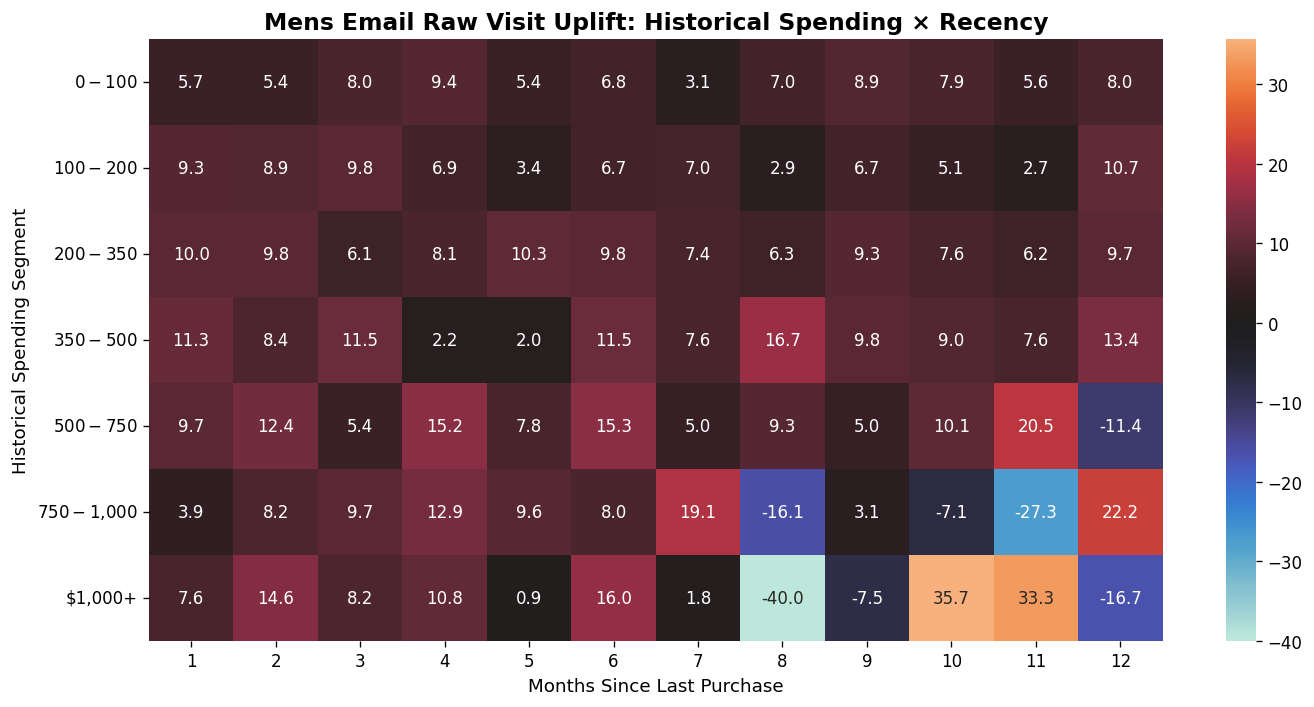

In [44]:
mens_heatmap = (mens_history_recency["raw_uplift_pp"].unstack("recency").reindex(history_order))

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(mens_heatmap,annot=True,fmt=".1f",center=0,ax=ax,)

ax.set_title("Mens Email Raw Visit Uplift: Historical Spending × Recency")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Historical Spending Segment")

plt.tight_layout()
plt.show()

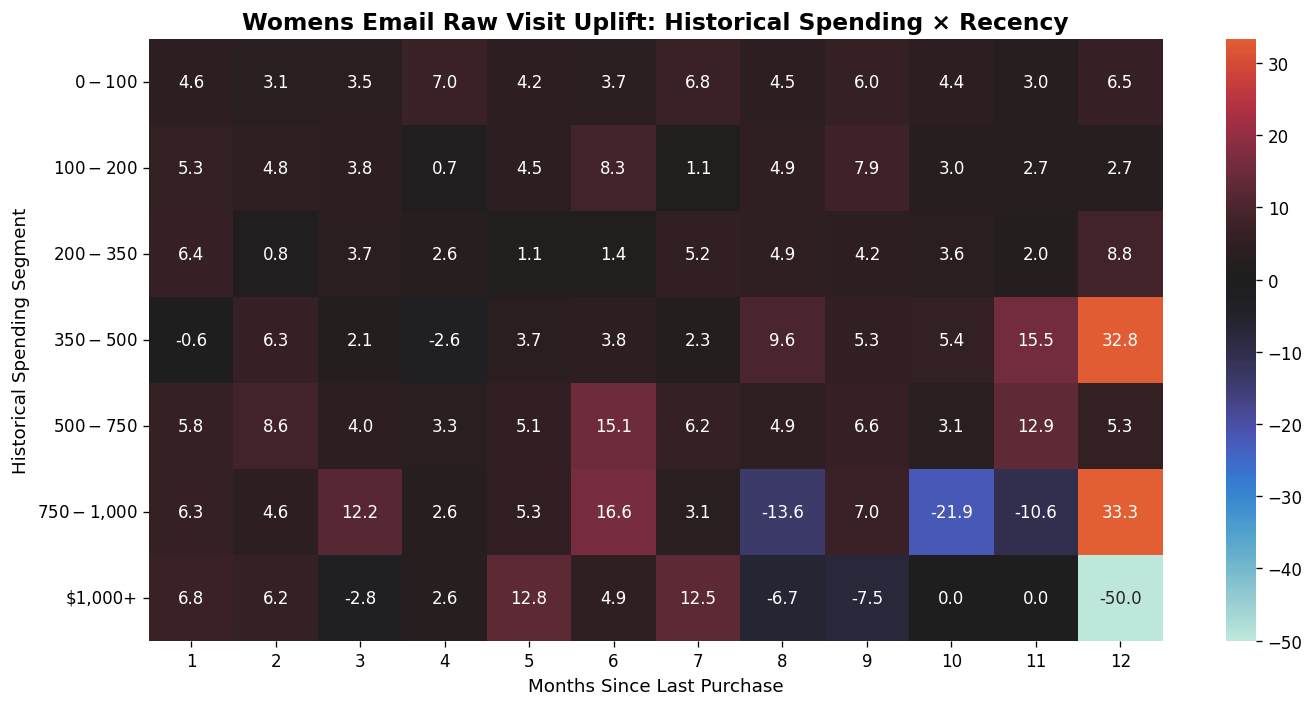

In [45]:
womens_heatmap = (womens_history_recency["raw_uplift_pp"].unstack("recency").reindex(history_order))

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(womens_heatmap,annot=True,fmt=".1f",center=0,ax=ax,)

ax.set_title("Womens Email Raw Visit Uplift: Historical Spending × Recency")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Historical Spending Segment")

plt.tight_layout()
plt.show()

In [46]:
zip_order = ["Rural", "Suburban", "Urban"]

mens_zip = subgroup_uplift(df, "zip_code", "Mens E-Mail").reindex(zip_order)
womens_zip = subgroup_uplift(df, "zip_code", "Womens E-Mail").reindex(zip_order)

zip_uplift = pd.DataFrame({
    "Mens E-Mail": mens_zip["raw_uplift_pp"],
    "Womens E-Mail": womens_zip["raw_uplift_pp"],
})

display(zip_uplift.round(2))

,Mens E-Mail,Womens E-Mail
zip_code,,
Rural,7.3400,2.9100
Suburban,7.4300,4.8900
Urban,7.9600,4.6900


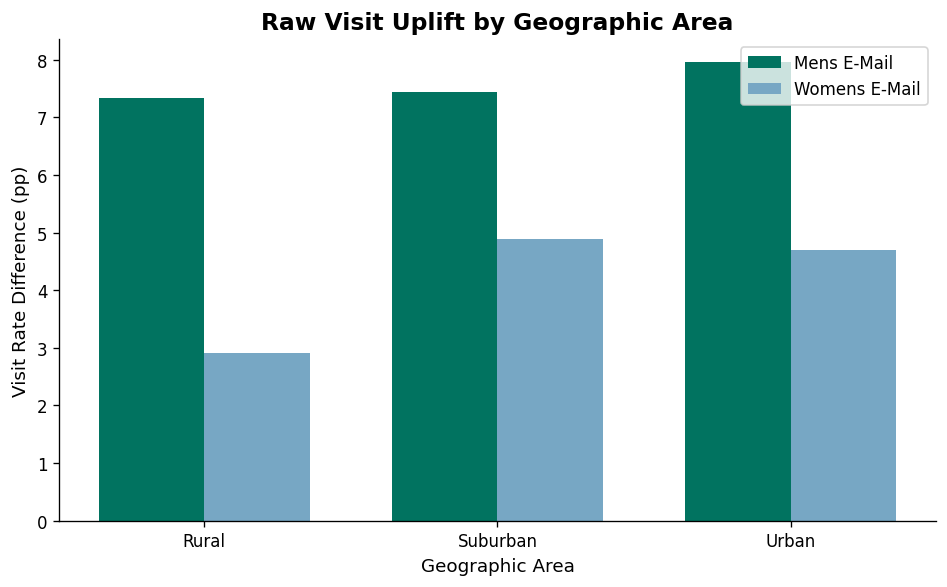

In [47]:
x = np.arange(len(zip_order))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    zip_uplift["Mens E-Mail"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    zip_uplift["Womens E-Mail"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.set_title("Raw Visit Uplift by Geographic Area")
ax.set_xlabel("Geographic Area")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(zip_order)
ax.legend()

plt.tight_layout()
plt.show()

- **Recency (time since the most recent purchase)**

  - Both campaigns show positive raw visit uplift across all recency groups.
  - `Mens E-Mail` has higher raw uplift in every group, ranging from roughly 5.6–8.7 pp, compared with about 3.0–7.4 pp for `Womens E-Mail`.
  - I do not see a clear increasing or decreasing relationship with recency. Instead, uplift fluctuates across the 12 groups.
  - The gap between the two campaigns is relatively large around months 2–4 and much smaller at month 12.

- **Purchase history (`mens/womens`)**

  - Customers who previously purchased only Mens products show an uplift of 6.92 pp for `Mens E-Mail`, compared with 1.11 pp for `Womens E-Mail`.
  - Customers who purchased only Womens products respond similarly to both campaigns, with uplift of 7.06 pp for `Mens E-Mail` and 7.40 pp for `Womens E-Mail`.
  - Customers who purchased both product categories show the largest uplift for `Mens E-Mail`, at 13.44 pp compared with 7.11 pp for `Womens E-Mail`.

- **Purchase channel (`channel`)**

  - Raw uplift changes very little across Web, Phone, and Multichannel customers.
  - For `Mens E-Mail`, the values are 7.56, 7.56, and 8.29 pp. For `Womens E-Mail`, they are 4.57, 4.46, and 4.71 pp.
  - I do not see a clear descriptive difference in treatment response across previous purchase channels.

- **Spending history (`history_segment`)**

  - Raw uplift does not increase consistently with historical spending.
  - The `$500–750` group has relatively high uplift for both campaigns, at about 9.9 pp for `Mens E-Mail` and 6.6 pp for `Womens E-Mail`.
  - When I also look at recency, the `$500–750` and `recency = 6` subgroup stands out, with uplift of about 15.3 pp for `Mens E-Mail` and 15.1 pp for `Womens E-Mail`.
  - The high-spending groups contain fewer observations, and their uplift values fluctuate substantially. I therefore do not treat the extreme values in these groups as stable patterns.
  - The `$500–750 × recency 6` subgroup is the main spending–recency pattern I examine further.

- **Shopping area (`zip_code`)**

  - `Mens E-Mail` is fairly stable across Rural, Suburban, and Urban customers, with uplift of 7.34, 7.43, and 7.96 pp.
  - `Womens E-Mail` shows more variation: Rural customers have 2.91 pp uplift, compared with 4.89 pp for Suburban and 4.69 pp for Urban customers.
  - Descriptively, geographic differences are more noticeable for `Womens E-Mail` than for `Mens E-Mail`.

### Statistical Testing Approach

I test treatment-effect heterogeneity using treatment-by-covariate interaction terms.

For the binary `visit` outcome, I use a Linear Probability Model (LPM), which allows the treatment and interaction coefficients to be interpreted directly on the percentage-point scale used above. I use HC3 heteroskedasticity-robust standard errors with a significance level of `α = 0.05`.

`conversion` is much rarer, so subgroup-level treatment-effect estimates are expected to be substantially less stable and are not used for the exploratory interaction tests below.


For categorical moderators with multiple levels, I use joint Wald tests to test whether the corresponding treatment-interaction terms are jointly equal to zero.

## Hypotheses

Based on the subgroup patterns above, I test the following questions for `visit`. Since these hypotheses are developed and evaluated using the same dataset, I treat the statistical results as exploratory rather than confirmatory evidence.

### H1 — Prior Product Affinity

**Research question:**  
Does visit uplift differ across customers with different prior product purchase patterns?

**H₀:** Treatment effects do not differ across prior product-affinity groups.

**H₁:** Treatment effects differ across at least one prior product-affinity group.

---

### H2 — Recency and Historical Spending

**Research question:**  
Do `recency` and `history_segment`, when included as separate moderators, show evidence of treatment-effect variation?

**H₀:** The treatment interactions with `recency` and `history_segment` are jointly equal to zero.

**H₁:** At least one of these treatment interactions is not equal to zero.

---

### H3 — $500–750 × Recency 6 Exploratory Follow-up

**Research question:**  
For each email campaign, does the treatment effect for the `$500–750 × recency 6` subgroup differ from that of the remaining customers?

The `Mens E-Mail` and `Womens E-Mail` treatment-interaction contrasts are evaluated separately.

---

### H4 — Geographic Area

**Research question:**  
Does visit uplift differ across geographic areas?

**H₀:** Treatment effects do not differ across geographic areas.

**H₁:** Treatment effects differ across at least one geographic area.


In [48]:
import statsmodels.formula.api as smf

outcome = "visit"

def joint_interaction_test(model, keywords):
    terms = [name for name in model.params.index if ":" in name and any(k in name for k in keywords)]
    R = np.zeros((len(terms), len(model.params)))

    for i, term in enumerate(terms):
        R[i, model.params.index.get_loc(term)] = 1

    test = model.wald_test(R, scalar=True)
    return float(test.statistic), float(test.pvalue)

In [49]:
h1_model = smf.ols(
    f'{outcome} ~ C(segment, Treatment(reference="No E-Mail")) * C(product_affinity)',
    data=product_df,
).fit(cov_type="HC3")

stat, p_value = joint_interaction_test(h1_model, ["product_affinity"])

print(f"H1 Wald statistic: {stat:.3f}")
print(f"H1 p-value: {p_value:.4f}")
print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

H1 Wald statistic: 130.961
H1 p-value: 0.0000
Reject H0


In [50]:
h2_model = smf.ols(
    f'{outcome} ~ C(segment, Treatment(reference="No E-Mail")) * C(recency) + '
    f'C(segment, Treatment(reference="No E-Mail")) * C(history_segment)',
    data=df,
).fit(cov_type="HC3")

stat, p_value = joint_interaction_test(h2_model, ["recency", "history_segment"])

print(f"H2 Wald statistic: {stat:.3f}")
print(f"H2 p-value: {p_value:.4f}")
print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

H2 Wald statistic: 39.001
H2 p-value: 0.2549
Fail to reject H0


In [51]:
for feature in ["recency", "history_segment"]:
    stat, p_value = joint_interaction_test(h2_model, [feature])
    print(f"{feature}: p-value = {p_value:.4f}")

recency: p-value = 0.4112
history_segment: p-value = 0.2398


In [52]:
h3_df = df.copy()
h3_df["target_group"] = (
    (h3_df["history_segment"] == "$500 - $750") &
    (h3_df["recency"] == 6)
).astype(int)

In [53]:
mens_h3 = subgroup_uplift(h3_df, "target_group", "Mens E-Mail", outcome=outcome)
womens_h3 = subgroup_uplift(h3_df, "target_group", "Womens E-Mail", outcome=outcome)

display(pd.DataFrame({
    "Mens E-Mail": mens_h3["raw_uplift_pp"],
    "Womens E-Mail": womens_h3["raw_uplift_pp"],
}).rename(index={0: "Other customers", 1: "$500–750 + recency 6"}).round(2))

,Mens E-Mail,Womens E-Mail
target_group,,
Other customers,7.6200,4.4700
$500–750 + recency 6,15.2600,15.0900


In [54]:
h3_model = smf.ols(
    f'{outcome} ~ C(segment, Treatment(reference="No E-Mail")) * target_group',
    data=h3_df,
).fit(cov_type="HC3")

for term in h3_model.params.index:
    if ":target_group" not in term:
        continue

    diff_pp = h3_model.params[term] * 100
    p_value = h3_model.pvalues[term]

    ci_low, ci_high = h3_model.conf_int().loc[term] * 100

    treatment = "Mens E-Mail" if "Mens E-Mail" in term else "Womens E-Mail"

    print(
        f"{treatment}: "
        f"difference = {diff_pp:.2f} pp, "
        f"95% CI = [{ci_low:.2f}, {ci_high:.2f}], "
        f"two-sided p = {p_value:.4f}"
    )

Mens E-Mail: difference = 7.63 pp, 95% CI = [-2.11, 17.38], two-sided p = 0.1248
Womens E-Mail: difference = 10.62 pp, 95% CI = [1.27, 19.96], two-sided p = 0.0260


In [55]:
h4_model = smf.ols(
    'visit ~ C(segment, Treatment(reference="No E-Mail")) * C(zip_code)',
    data=df,
).fit(cov_type="HC3")

stat, p_value = joint_interaction_test(h4_model, ["zip_code"])

print(f"H4 Wald statistic: {stat:.3f}")
print(f"H4 p-value: {p_value:.4f}")
print("Reject H0" if p_value < 0.05 else "Fail to reject H0")

H4 Wald statistic: 4.807
H4 p-value: 0.3077
Fail to reject H0


### Hypothesis Testing Conclusion

- **H1 — Prior Product Affinity:** I reject H₀ (`p < 0.001`). Among the tested customer characteristics, prior product affinity provides the strongest exploratory evidence of treatment-effect heterogeneity.

- **H2 — Recency and Historical Spending:** I fail to reject H₀ (`p = 0.2549`). The separate tests for `recency` (`p = 0.4112`) and `history_segment` (`p = 0.2398`) lead to the same conclusion. The differences observed during EDA are therefore not supported as systematic treatment-effect variation under the current specification.

- **H3 — $500–750 × Recency 6:** Compared with the remaining customers, this subgroup has an estimated treatment-effect difference of **+7.63 pp** for `Mens E-Mail` (`95% CI [-2.11, 17.38]`, `p = 0.1248`) and **+10.62 pp** for `Womens E-Mail` (`95% CI [1.27, 19.96]`, `p = 0.0260`). The `Womens E-Mail` contrast is nominally below `α = 0.05`, but this subgroup was identified from the same exploratory analysis. I therefore treat it as hypothesis-generating evidence rather than a confirmatory finding.

- **H4 — Geographic Area:** I fail to reject H₀ (`p = 0.3077`). The lower raw uplift observed for Rural customers under `Womens E-Mail` is not supported as systematic geographic treatment-effect variation by the joint test.

Overall, the exploratory tests provide the clearest evidence of heterogeneity for prior product affinity. The remaining patterns are retained as exploratory observations rather than being used directly to define targeting rules or engineered subgroup features.

## Feature Engineering

For modeling, I use only pre-treatment customer information.

- `recency`: kept as a numeric feature.
- `history`: kept as the original numeric spending value. `history_segment` is used for EDA only.
- `mens` and `womens`: combined into `product_affinity` (`Mens only`, `Womens only`, `Both`) to represent prior product purchase patterns directly.
- `channel`: kept as a categorical feature.
- `zip_code`: kept as a categorical feature.
- `newbie`: kept as a binary feature.

I do not create separate features for individual EDA patterns such as `recency = 6` or `$500–750 × recency 6`.

In [56]:
feature_df = df.copy()

feature_df["product_affinity"] = np.select(
    [
        (feature_df["mens"] == 1) & (feature_df["womens"] == 0),
        (feature_df["mens"] == 0) & (feature_df["womens"] == 1),
        (feature_df["mens"] == 1) & (feature_df["womens"] == 1),
    ],
    ["Mens only", "Womens only", "Both"],
    default="Neither",
)

feature_columns = ["recency", "history", "product_affinity", "channel", "zip_code", "newbie"]
feature_df = feature_df[feature_columns + ["segment", "visit", "conversion"]].copy()

display(feature_df.head())
print(feature_df.dtypes)

,recency,history,product_affinity,channel,zip_code,newbie,segment,visit,conversion
0,10,142.4400,Mens only,Phone,Suburban,0,Womens E-Mail,0,0
1,6,329.0800,Both,Web,Rural,1,No E-Mail,0,0
2,7,180.6500,Womens only,Web,Suburban,1,Womens E-Mail,0,0
3,9,675.8300,Mens only,Web,Rural,1,Mens E-Mail,0,0
4,2,45.3400,Mens only,Web,Urban,0,Womens E-Mail,0,0


recency               int64
history             float64
product_affinity     object
channel              object
zip_code             object
newbie                int64
segment              object
visit                 int64
conversion            int64
dtype: object


In [57]:
categorical_columns = ["product_affinity", "channel", "zip_code"]

prepared_df = pd.get_dummies(
    feature_df,
    columns=categorical_columns,
    dtype=int,
)

display(prepared_df.head())

,recency,history,newbie,segment,visit,conversion,product_affinity_Both,product_affinity_Mens only,product_affinity_Womens only,channel_Multichannel,channel_Phone,channel_Web,zip_code_Rural,zip_code_Suburban,zip_code_Urban
0,10,142.4400,0,Womens E-Mail,0,0,0,1,0,0,1,0,0,1,0
1,6,329.0800,1,No E-Mail,0,0,1,0,0,0,0,1,1,0,0
2,7,180.6500,1,Womens E-Mail,0,0,0,0,1,0,0,1,0,1,0
3,9,675.8300,1,Mens E-Mail,0,0,0,1,0,0,0,1,1,0,0
4,2,45.3400,0,Womens E-Mail,0,0,0,1,0,0,0,1,0,0,1


In [58]:
mens_df = prepared_df[prepared_df["segment"].isin(["No E-Mail", "Mens E-Mail"])].copy()

mens_df["treatment"] = (mens_df["segment"] == "Mens E-Mail").astype(int)
mens_df = mens_df.drop(columns="segment")

print(mens_df["treatment"].value_counts())
display(mens_df.head())

treatment
1    21307
0    21306
Name: count, dtype: int64


,recency,history,newbie,visit,conversion,product_affinity_Both,product_affinity_Mens only,product_affinity_Womens only,channel_Multichannel,channel_Phone,channel_Web,zip_code_Rural,zip_code_Suburban,zip_code_Urban,treatment
1,6,329.0800,1,0,0,1,0,0,0,0,1,1,0,0,0
3,9,675.8300,1,0,0,0,1,0,0,0,1,1,0,0,1
8,9,675.0700,1,0,0,1,0,0,0,1,0,1,0,0,1
13,2,101.6400,0,1,0,0,0,1,0,0,1,0,0,1,1
14,4,241.4200,1,0,0,0,0,1,1,0,0,1,0,0,0


In [59]:
womens_df = prepared_df[prepared_df["segment"].isin(["No E-Mail", "Womens E-Mail"])].copy()

womens_df["treatment"] = (womens_df["segment"] == "Womens E-Mail").astype(int)
womens_df = womens_df.drop(columns="segment")

print(womens_df["treatment"].value_counts())
display(womens_df.head())

treatment
1    21387
0    21306
Name: count, dtype: int64


,recency,history,newbie,visit,conversion,product_affinity_Both,product_affinity_Mens only,product_affinity_Womens only,channel_Multichannel,channel_Phone,channel_Web,zip_code_Rural,zip_code_Suburban,zip_code_Urban,treatment
0,10,142.4400,0,0,0,0,1,0,0,1,0,0,1,0,1
1,6,329.0800,1,0,0,1,0,0,0,0,1,1,0,0,0
2,7,180.6500,1,0,0,0,0,1,0,0,1,0,1,0,1
4,2,45.3400,0,0,0,0,1,0,0,0,1,0,0,1,1
5,6,134.8300,0,1,0,0,0,1,0,1,0,0,1,0,1


In [60]:
outcome_columns = ["visit", "conversion"]
feature_cols = [c for c in mens_df.columns if c not in ["treatment", *outcome_columns]]

print(f"Features: {len(feature_cols)}")
print(feature_cols)

print("\nMens dataset:", mens_df.shape)
print("Womens dataset:", womens_df.shape)

for name, data in [("Mens", mens_df), ("Womens", womens_df)]:
    assert not data.isna().any().any()
    assert set(data["treatment"].unique()) == {0, 1}
    assert set(data["visit"].unique()).issubset({0, 1})
    assert set(data["conversion"].unique()).issubset({0, 1})
    print(f"{name}: OK")

Features: 12
['recency', 'history', 'newbie', 'product_affinity_Both', 'product_affinity_Mens only', 'product_affinity_Womens only', 'channel_Multichannel', 'channel_Phone', 'channel_Web', 'zip_code_Rural', 'zip_code_Suburban', 'zip_code_Urban']

Mens dataset: (42613, 15)
Womens dataset: (42693, 15)
Mens: OK
Womens: OK


In [61]:
INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "hillstrom"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

MENS_PREPARED_PATH = INTERIM_DIR / "hillstrom_mens_prepared.parquet"
WOMENS_PREPARED_PATH = INTERIM_DIR / "hillstrom_womens_prepared.parquet"

mens_df.to_parquet(
    MENS_PREPARED_PATH,
    index=False,
)

womens_df.to_parquet(
    WOMENS_PREPARED_PATH,
    index=False,
)

print("Mens prepared dataset:", MENS_PREPARED_PATH)
print("Womens prepared dataset:", WOMENS_PREPARED_PATH)

Mens prepared dataset: d:\thao\d\uplif_model\uplif_customer_selection\data\interim\hillstrom\hillstrom_mens_prepared.parquet
Womens prepared dataset: d:\thao\d\uplif_model\uplif_customer_selection\data\interim\hillstrom\hillstrom_womens_prepared.parquet
